<a href="https://colab.research.google.com/github/quratulain-nayeem/shap/blob/master/positive_vs_negative_sentiment_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Positive vs. Negative Sentiment Classification

In this notebook, we demonstrate how to interpret a sentiment classification model using SHAP. The goal is to understand how individual words in a movie review influence the model's prediction of positive or negative sentiment.

In [ ]:
import datasets
import numpy as np
import transformers

import shap

## Load the IMDB movie review dataset

In [ ]:
# Load IMDB dataset (movie reviews labeled as positive/negative)
dataset = datasets.load_dataset("imdb", split="test")

# shorten the strings to fit into the pipeline model
short_data = [v[:500] for v in dataset["text"][:20]]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## Load and run a sentiment analysis pipeline

In [ ]:
# Load pretrained sentiment analysis model from HuggingFace
# Note: Model will be downloaded on first run
classifier = transformers.pipeline("sentiment-analysis", top_k=None)
classifier(short_data[:2])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[[{'label': 'POSITIVE', 'score': 0.9241790771484375},
  {'label': 'NEGATIVE', 'score': 0.07582096010446548}],
 [{'label': 'POSITIVE', 'score': 0.9816575050354004},
  {'label': 'NEGATIVE', 'score': 0.018342452123761177}]]

## Explain the sentiment analysis pipeline

In [ ]:
# Create SHAP explainer to compute word-level importance
explainer = shap.Explainer(classifier)

In [ ]:
# explain the predictions of the pipeline on the first two samples
shap_values = explainer(short_data[:2])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:48, 114.47s/it]


In [ ]:
# Visualize contribution of each word to the prediction for the "POSITIVE" class
shap.plots.text(shap_values[:, :, "POSITIVE"])

## Wrap the pipeline manually

SHAP explanations operate best in additive feature spaces. Since probabilities are not additive, we convert them into logits (log-odds). This ensures that SHAP values correctly sum up to the model output.

### Create a TransformersPipeline wrapper

In [ ]:
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=False)

In [ ]:
pmodel(short_data[:2])

array([[0.        , 0.92417908],
       [0.        , 0.98165751]])

In [ ]:
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=True)
pmodel(short_data[:2])

array([[0.        , 2.50053158],
       [0.        , 3.98002198]])

In [ ]:
explainer2 = shap.Explainer(pmodel)
shap_values2 = explainer2(short_data[:2])
shap.plots.text(shap_values2[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:44, 112.11s/it]


### Pass a tokenizer as the masker object

In [ ]:
explainer2 = shap.Explainer(pmodel, classifier.tokenizer)
shap_values2 = explainer2(short_data[:2])
shap.plots.text(shap_values2[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:52, 116.08s/it]


### Build a Text masker explicitly

In [ ]:
masker = shap.maskers.Text(classifier.tokenizer)
explainer2 = shap.Explainer(pmodel, masker)
shap_values2 = explainer2(short_data[:2])
shap.plots.text(shap_values2[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [03:48, 114.48s/it]


## Explore how the Text masker works

In [ ]:
masker.shape("I like this movie.")

(1, 7)

In [ ]:
model_args = masker(np.array([True, True, True, True, True, True, True]), "I like this movie.")
model_args

(array(['I like this movie.'], dtype='<U18'),)

In [ ]:
pmodel(*model_args)

array([[0.        , 8.90786191]])

In [ ]:
model_args = masker(np.array([True, True, False, False, True, True, True]), "I like this movie.")
model_args

(array(['I [MASK] [MASK]movie.'], dtype='<U21'),)

In [ ]:
pmodel(*model_args)

array([[0.        , 3.72091284]])

In [ ]:
masker2 = shap.maskers.Text(classifier.tokenizer, mask_token="...", collapse_mask_token=True)

In [ ]:
model_args2 = masker2(np.array([True, True, False, False, True, True, True]), "I like this movie.")
model_args2

(array(['I ...movie.'], dtype='<U11'),)

In [ ]:
pmodel(*model_args2)

array([[0.        , 3.20817796]])

## Plot summary statistics and bar charts

In [ ]:
# explain the predictions of the pipeline on the first two samples
shap_values = explainer(short_data[:20])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|█▌        | 3/20 [03:44<14:35, 51.51s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  95%|█████████▌| 19/20 [34:39<01:53, 113.24s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 20/20 [36:41<00:00, 115.84s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [38:50, 116.50s/it]


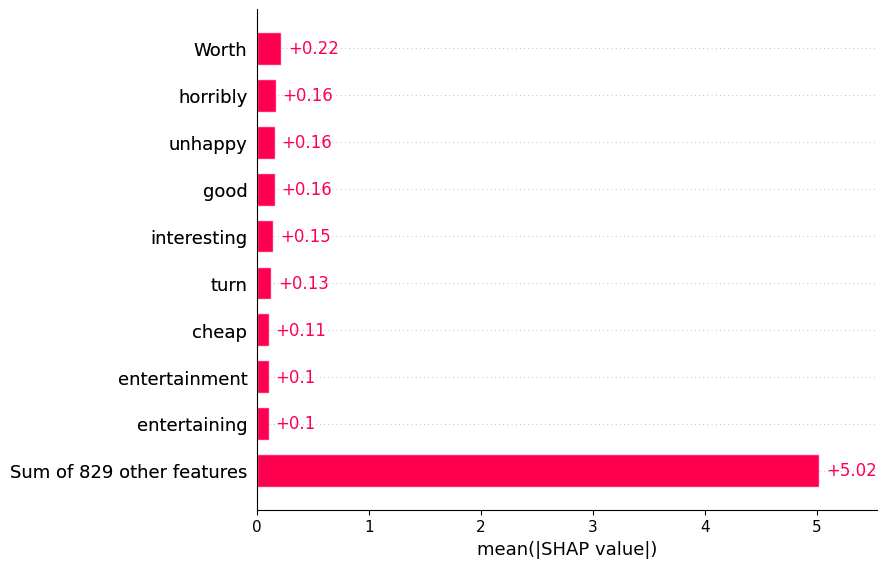

In [ ]:
shap.plots.bar(shap_values[:, :, "POSITIVE"])

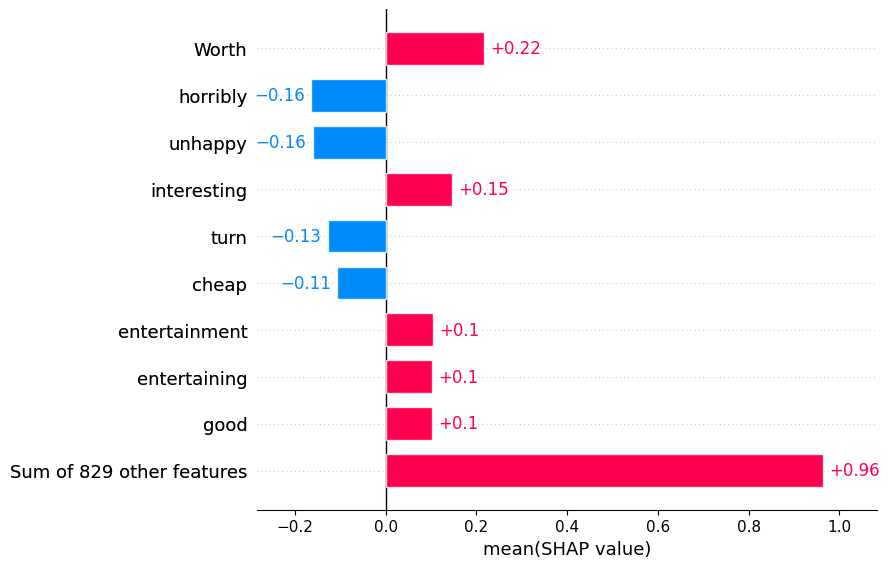

In [ ]:
shap.plots.bar(shap_values[:, :, "POSITIVE"].mean(0))

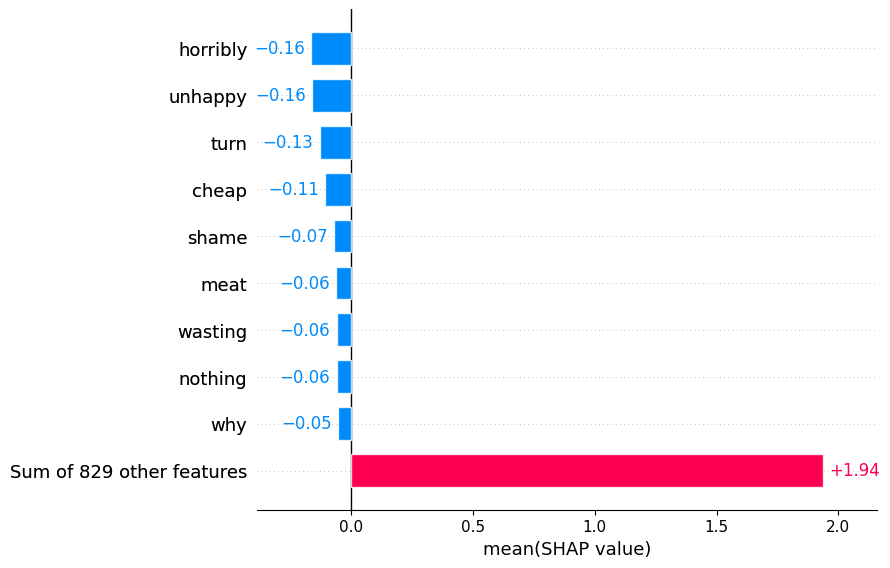

In [ ]:
shap.plots.bar(shap_values[:, :, "POSITIVE"].mean(0), order=shap.Explanation.argsort)